# Iteration 1: Baseline CNN

This notebook establishes a simple CNN baseline for the automated online exam proctoring classifier.

## What problem are we solving, and how will we know?

This first iteration creates the baseline model, so there is no previous model to improve yet. The main goal is to measure how a simple 3-layer CNN behaves on the finalized dataset and identify its weaknesses.

We will know what problem to solve next by comparing training and validation curves, along with the confusion matrix. If training accuracy becomes much higher than validation accuracy, that is evidence of overfitting and weak generalization.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Stability mode

from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
GROUP_CHUNK_SIZE = 20
AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.10.0


In [2]:
# Force CPU mode for DirectML stability
try:
    tf.config.set_visible_devices([], 'GPU')
except Exception as error:
    print('GPU visibility already fixed:', error)

print('Visible GPUs:', tf.config.get_visible_devices('GPU'))


Visible GPUs: []


In [3]:
def find_dataset_root() -> Path:
    candidates = [
        Path.cwd() / 'Dataset',
        Path.cwd().parent / 'Dataset',
        Path.cwd().parent.parent / 'Dataset',
        Path('C:/Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk/DLProject/Dataset')
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            class_dirs = [p for p in candidate.iterdir() if p.is_dir()]
            if class_dirs:
                return candidate.resolve()
    raise FileNotFoundError('Could not find the finalized Dataset folder.')

def natural_key(path: Path):
    parts = re.split(r'(\d+)', path.stem)
    return [int(part) if part.isdigit() else part.lower() for part in parts]

def extract_group_key(path: Path) -> str:
    match = re.search(r'(\d+)$', path.stem)
    chunk_id = int(match.group(1)) // GROUP_CHUNK_SIZE if match else 0
    prefix = re.sub(r'[_-]?\d+$', '', path.stem)
    return f'{path.parent.name}::{prefix}::chunk_{chunk_id:04d}'

def build_split_lists(dataset_root: Path, val_split: float = VAL_SPLIT):
    class_names = sorted([p.name for p in dataset_root.iterdir() if p.is_dir()])
    train_paths, train_labels = [], []
    val_paths, val_labels = [], []
    split_summary = []

    for class_index, class_name in enumerate(class_names):
        class_dir = dataset_root / class_name
        class_files = sorted([p for p in class_dir.iterdir() if p.is_file()], key=natural_key)
        grouped_files = {}
        for file_path in class_files:
            group_key = extract_group_key(file_path)
            grouped_files.setdefault(group_key, []).append(str(file_path))

        ordered_groups = sorted(grouped_files.items(), key=lambda item: item[0])
        val_group_count = max(1, int(round(len(ordered_groups) * val_split)))
        val_group_keys = {group_key for group_key, _ in ordered_groups[-val_group_count:]}

        class_train = 0
        class_val = 0
        for group_key, grouped_paths in ordered_groups:
            target_paths, target_labels = (val_paths, val_labels) if group_key in val_group_keys else (train_paths, train_labels)
            target_paths.extend(grouped_paths)
            target_labels.extend([class_index] * len(grouped_paths))
            if group_key in val_group_keys:
                class_val += len(grouped_paths)
            else:
                class_train += len(grouped_paths)

        split_summary.append({
            'class_name': class_name,
            'groups': len(ordered_groups),
            'train_images': class_train,
            'val_images': class_val
        })

    return class_names, train_paths, train_labels, val_paths, val_labels, split_summary

def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(paths, labels, training=False):
    path_arr = np.array(paths)
    label_arr = np.array(labels, dtype=np.int32)

    if training and len(path_arr) > 0:
        rng = np.random.default_rng(SEED)
        order = rng.permutation(len(path_arr))
        path_arr = path_arr[order]
        label_arr = label_arr[order]

    ds = tf.data.Dataset.from_tensor_slices((path_arr, label_arr))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

DATASET_ROOT = find_dataset_root()
CLASS_NAMES, train_paths, train_labels, val_paths, val_labels, split_summary = build_split_lists(DATASET_ROOT)
NUM_CLASSES = len(CLASS_NAMES)

print('Dataset root:', DATASET_ROOT)
print('Classes:', CLASS_NAMES)
print('Number of classes:', NUM_CLASSES)
print('Train images:', len(train_paths))
print('Validation images:', len(val_paths))
print('Sequence-aware split summary:')
for row in split_summary:
    print(row)

Dataset root: C:\Users\user\Documents\GitHub\behavior-detection\DLProject\Dataset
Classes: ['distracted', 'fatigue', 'focused', 'raise_hand', 'sleeping', 'using_smartphone', 'writing_reading']
Number of classes: 7
Train images: 6863
Validation images: 1697
Sequence-aware split summary:
{'class_name': 'distracted', 'groups': 80, 'train_images': 1181, 'val_images': 301}
{'class_name': 'fatigue', 'groups': 52, 'train_images': 714, 'val_images': 172}
{'class_name': 'focused', 'groups': 146, 'train_images': 2285, 'val_images': 573}
{'class_name': 'raise_hand', 'groups': 54, 'train_images': 683, 'val_images': 177}
{'class_name': 'sleeping', 'groups': 41, 'train_images': 637, 'val_images': 152}
{'class_name': 'using_smartphone', 'groups': 25, 'train_images': 348, 'val_images': 88}
{'class_name': 'writing_reading', 'groups': 65, 'train_images': 1015, 'val_images': 234}


In [4]:
train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
class_names = CLASS_NAMES

print('Class names from loader:', class_names)

Class names from loader: ['distracted', 'fatigue', 'focused', 'raise_hand', 'sleeping', 'using_smartphone', 'writing_reading']


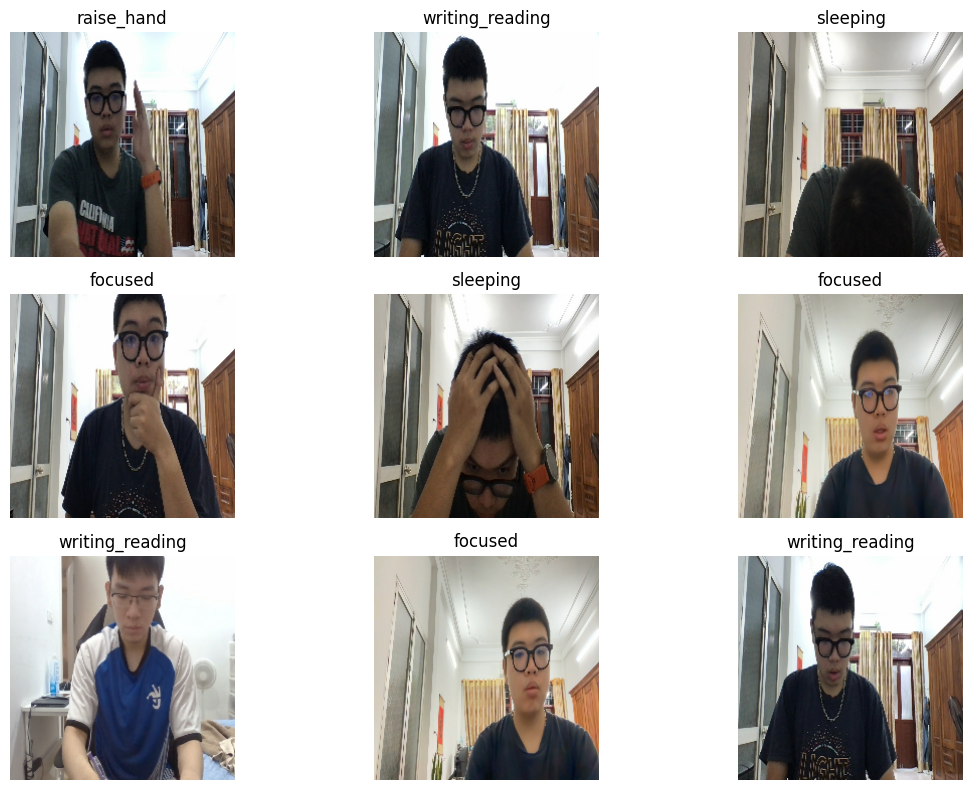

In [5]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout()

In [6]:
baseline_model = keras.Sequential([
    layers.Rescaling(1.0 / 255, input_shape=IMG_SIZE + (3,)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 128)       7

In [7]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
215/215 [==============================] - 115s 534ms/step - loss: 0.1440 - accuracy: 0.9556 - val_loss: 5.7568 - val_accuracy: 0.5486
Epoch 2/15
215/215 [==============================] - 115s 534ms/step - loss: 3.8577e-05 - accuracy: 1.0000 - val_loss: 6.4237 - val_accuracy: 0.5474
Epoch 3/15
215/215 [==============================] - 107s 497ms/step - loss: 1.5826e-05 - accuracy: 1.0000 - val_loss: 6.7853 - val_accuracy: 0.5463
Epoch 4/15
215/215 [==============================] - 107s 499ms/step - loss: 8.7219e-06 - accuracy: 1.0000 - val_loss: 7.0487 - val_accuracy: 0.5457
Epoch 5/15
215/215 [==============================] - 107s 498ms/step - loss: 5.4353e-06 - accuracy: 1.0000 - val_loss: 7.2824 - val_accuracy: 0.5457


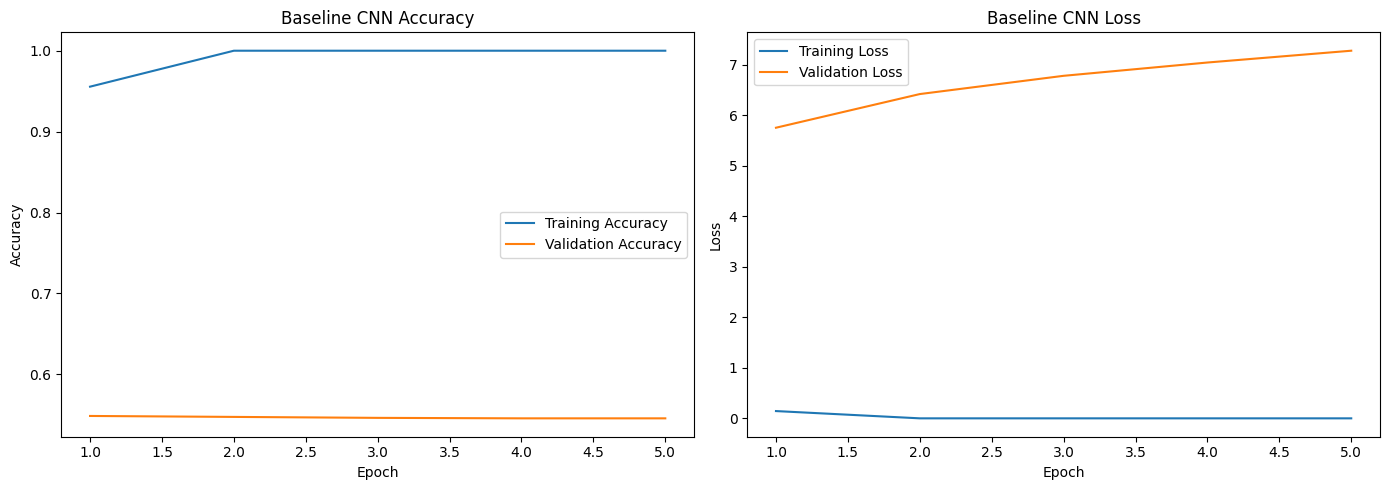

In [8]:
def plot_history(history, title_prefix='Model'):
    history_dict = history.history
    epochs = range(1, len(history_dict['loss']) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_dict['accuracy'], label='Training Accuracy')
    plt.plot(epochs, history_dict['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_dict['loss'], label='Training Loss')
    plt.plot(epochs, history_dict['val_loss'], label='Validation Loss')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()

plot_history(history, 'Baseline CNN')

54/54 [==============================] - 6s 113ms/step
                  precision    recall  f1-score   support

      distracted       0.70      0.97      0.82       301
         fatigue       1.00      0.12      0.21       172
         focused       0.79      0.21      0.33       573
      raise_hand       0.41      1.00      0.58       177
        sleeping       0.00      0.00      0.00       152
using_smartphone       1.00      1.00      1.00        88
 writing_reading       0.40      1.00      0.57       234

        accuracy                           0.55      1697
       macro avg       0.61      0.61      0.50      1697
    weighted avg       0.64      0.55      0.47      1697



c:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\.venv310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\.venv310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\.venv310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

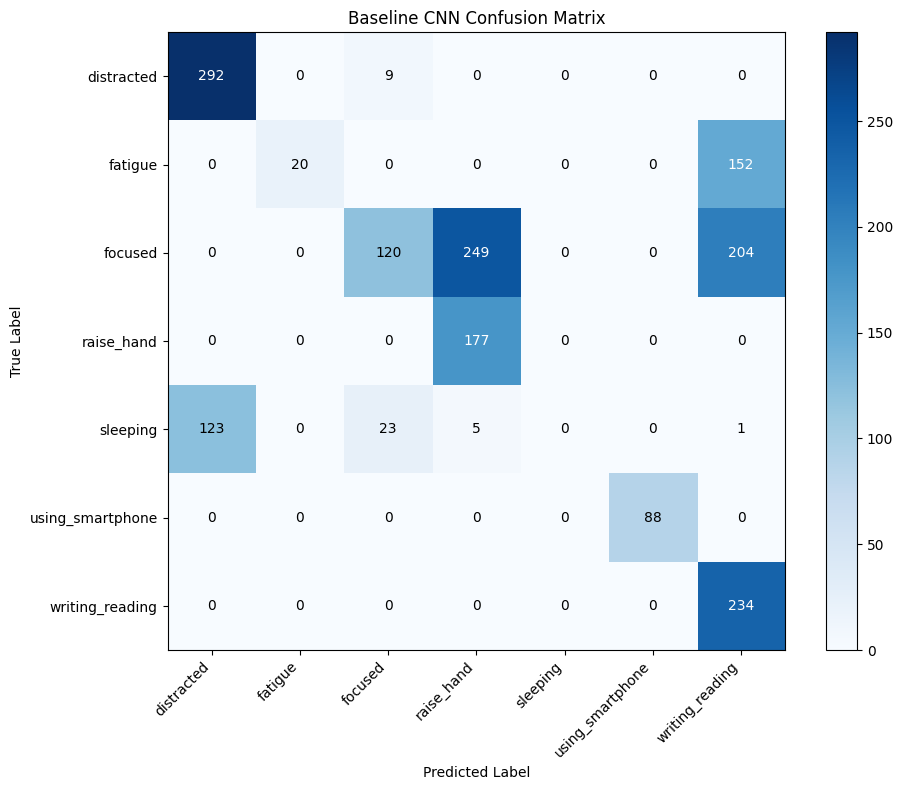

In [9]:
y_true = np.concatenate([labels.numpy() for _, labels in val_ds], axis=0)
y_prob = baseline_model.predict(val_ds)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.title('Baseline CNN Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

threshold = cm.max() / 2 if cm.max() > 0 else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > threshold else 'black')
plt.tight_layout()

print(classification_report(y_true, y_pred, target_names=class_names))

## Evidence Summary

Expected outcome for this baseline after fixing leakage: training accuracy may still rise strongly, but validation accuracy should now be more realistic because the validation set contains held-out frame chunks rather than random neighboring frames from the same sequences.

The next iteration will address that by replacing the small custom feature extractor with MobileNetV2 transfer learning, which should provide stronger visual features and better validation performance.